## 📋 Overview
This notebook creates training data for paleotopography modeling by:
1. Extracting subduction zone parameters from plate reconstruction models
2. Calculating mantle convection properties at various depths
3. Computing climate parameters (time spent in humid belts)
4. Sampling oceanic lithospheric age
5. Combining all parameters into training datasets

**Required time**: Several hours depending on time range and resolution settings.


# Import Libraries

This part of code will import all the necessary libraries required for the code



In this section, we import all the necessary libraries required for building and training the machine learning model. The libraries include custom modules and standard Python packages for data manipulation, geographical computations, and machine learning.

- **pyDTDM.BhuDM**: Custom module for data management and machine learning code used in this project.
- **pyDTDM.utils**: Custom utilities for various functions used in the workflow.
- **warnings**: Module to handle and control warnings during execution.
- **yaml**: Library for parsing YAML files. We use `Cloader` for faster loading if available.
- **ptt**: Custom or third-party module for specific functionalities not detailed here.
- **shapely**: Library for manipulation and analysis of planar geometric objects.
- **pandas**: Library for data manipulation and analysis.
- **geopandas**: Extends pandas to support spatial operations.
- **numpy**: Library for numerical operations and array handling.

In [2]:
import os
import netCDF4  #prevent hdf stray error because of multiple imports of libraries dealing with hdf5

from pyDTDM import *
import warnings
import yaml
try:
    from yaml import Cloader as Loader
except ImportError:

    from yaml import Loader

import ptt
import shapely
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

from geopy.distance import geodesic
from geopy import Point as GeopyPoint
import cmcrameri.cm as cmc
from joblib import Parallel, delayed
import os



import pyproj
# Point pyproj to the correct PROJ data directory
os.environ["PROJ_LIB"] = "/Users/ssin4735/miniforge3/envs/EBMTest311/share/proj"
pyproj.datadir.set_data_dir(os.environ["PROJ_LIB"])

/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



## 🔧 Setup and Configuration

### Configuration File
The workflow is controlled by a YAML configuration file that specifies:
- Plate kinematic model files (topology, rotations, coastlines, etc.)
- Mantle convection model data paths
- Output parameters (time range, resolution, compression)
- Reference frames (mantle-optimized vs paleomagnetic)

**Current config**: `InputFiles/Merdith1Ga.yaml`


# Load Configuration/Input File

The input file can be changed to include other parameters as well

In [8]:
config_file="InputFiles/Merdith1Ga.yaml"
with open(config_file) as f:
    PARAMS = yaml.load(f, Loader=Loader)
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(" Parameters set from %s" % config_file)
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")


––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
 Parameters set from InputFiles/Merdith1Ga.yaml
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


### Reading the input file

In [9]:
# Input Files 
MODEL_NAME=PARAMS['InputFiles']['plate_kinematics']['model_name'] # model name
MODEL_DIR = PARAMS['InputFiles']['plate_kinematics']['model_dir']  ## plate model location
topology_filenames =[f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['plate_kinematics']['topology_files']]
rotation_filenames = [f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['plate_kinematics']['rotation_files']]
agegrid=PARAMS['InputFiles']['plate_kinematics']['agegrid'] ## agegrid location

ETOPO_FILE=PARAMS['InputFiles']['Raster']['ETOPO_FILE'] # ETOPO grid in meters (can be netCDf or GeoTiff)
ETOPO_Type=PARAMS['InputFiles']['Raster']['Raster_type']
coastlines = f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['coastline_file']}"
static_polygon_file=f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['static_polygon']}"
static_polygons = pygplates.FeatureCollection(static_polygon_file)
continents=f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['continents']}"
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print("Reading input file..... \n")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"Plate Model: {MODEL_NAME} \n")
print(f"Model Directory: {MODEL_DIR} \n")
print(f"Coastlines: {coastlines} \n")
print(f"Continents: {continents} \n")
print(f"Static Polygons: {static_polygon_file} \n")
print(f"Model Agegrid: {agegrid} \n")
print(f"ETopo grid: {ETOPO_FILE}")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– \n")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Reading input file..... 

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Plate Model: Merdith1Ga 

Model Directory: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions 

Coastlines: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/StaticGeometries/GSHHS_l_coastlines.shp 

Continents: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/shapes_continents.shp 

Static Polygons: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/shapes_static_polygons.shp 

Model Agegrid: //Volumes/SatyamData/Merdith1Ga/Merdith_etal_OPTIMISED_gplately2/seafloor_grid_output/SEAFLOOR_AGE/masked/ 

ETopo grid: /Users/ssin4735/Documents/PROJECT/PhD Project/Codes and Data/Part 2/A_DEEPTIMETOPO/Data/Smoothed ETopo.tif
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 



## 📊 Model Parameters Explanation

### Key Parameters:
- **MESH_REFINEMENT_LEVEL**: Controls density of crustal points (0 = ~20° spacing, each increment halves the spacing)
- **WINDOW_SIZE**: Time window in Ma for averaging subduction parameters
- **Weighted**: Whether to use weighted mean for time-averaged calculations
- **NETCDF_GRID_RESOLUTION**: Grid spacing in degrees for output files
- **parallel**: Number of CPU cores to use (-1 = all available)

### Reference Frames:
- **Mantle_ID**: Anchor plate ID for mantle-optimized reference frame
- **Paleomag_ID**: Anchor plate ID for paleomagnetic reference frame

---

### Setting model parameters

In [10]:
Paleomag_ID=PARAMS['Parameters']['paleomag_id']
Mantle_ID=PARAMS['Parameters']['mantle_optimised_id']

#The initial positions of crustal points are evenly distributed within the designated region. 
# At mesh refinement level zero, the points are approximately 20 degrees apart.
# Each increase in the density level results in a halving of the spacing between points.
MESH_REFINEMENT_LEVEL=PARAMS['Parameters']['mesh_refinement_level']  # higher refinement level will take longer time to run for optimisation 
WINDOW_SIZE=int(PARAMS['Parameters']['time_window_size'])
Weighted=PARAMS['Parameters']['weighted_mean']


NETCDF_GRID_RESOLUTION=PARAMS['GridParameters']['grid_spacing']  # in degree
ZLIB=PARAMS['GridParameters']['compression']['zlib'] 
COMPLEVEL=PARAMS['GridParameters']['compression']['complevel'] 

FROM_TIME=int(PARAMS['TimeParameters']['time_max'])
TO_TIME=int(PARAMS['TimeParameters']['time_min'])
TIME_STEPS=int(PARAMS['TimeParameters']['time_step'])




parallel=PARAMS['Parameters']['number_of_cpus']### No of core to use or None for single core


print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print("The following parameters are set-")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"Mantle Optmised Reference Frame ID: {Mantle_ID}")
print(f"Paleomagnetic Reference Frame ID: {Paleomag_ID} \n")

print(f"Moving Window Size: {WINDOW_SIZE}")
print(f"Weighted Mean: {Weighted}")

print(f"Mesh Refinement Level: {MESH_REFINEMENT_LEVEL}")
print(f"NetCDF GRID Resolution: {NETCDF_GRID_RESOLUTION}")
print(f"NetCDF Compression Level: {COMPLEVEL} \n")
print(f"Model Start Time: {FROM_TIME}")
print(f"Model End Time: {TO_TIME}")
print(f"Model Time Step: {TIME_STEPS}\n")


print(f"Number of CPU: {parallel}") # -1 means all the freely available CPU


print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
The following parameters are set-
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Mantle Optmised Reference Frame ID: 0
Paleomagnetic Reference Frame ID: 0 

Moving Window Size: 25
Weighted Mean: True
Mesh Refinement Level: 9
NetCDF GRID Resolution: 0.1
NetCDF Compression Level: 5 

Model Start Time: 525
Model End Time: 0
Model Time Step: 1

Number of CPU: -1
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


## 🗂️ Output Structure

The workflow creates two main output folders:

### CSV Folder
Stores data in Parquet format (compressed tabular data):
- `ALL_Subduction.parquet`: Tessellated subduction zones for all times
- `Window_Size_X_Ma/`: Raw training data with plate kinematics
- `Processed_X_Ma/`: Complete training data with mantle & climate parameters

### NetCDF Folder
Stores gridded data that can be visualized in GPlates:
- `Interpolated_Seafloor/`: Lithospheric age grids



### Creating Output File

The output will be stored in the output folder: Paleotopography

There will be two folder:
- CSV Folder: to store data in tabular format. Here I have used paraquet file because it reduces the storage 
- NetCDF Folder: to store final NetCDF that can be visualised in GPlates


In [11]:
# Output Directory
OUTPUT_FOLDER=PARAMS['OutputFiles']['output_dir']

DEFAULT_OUTPUT_CSV=os.path.join(OUTPUT_FOLDER,'CSV')  # folder to store output in Tabular format
DEFAULT_OUTPUT_NetCDF=os.path.join(OUTPUT_FOLDER,'NetCDF') # folder to store output NetCDF grid





print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"All the output will be saved in {OUTPUT_FOLDER}")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
create_directory_if_not_exists(OUTPUT_FOLDER)
create_directory_if_not_exists(DEFAULT_OUTPUT_CSV)
create_directory_if_not_exists(DEFAULT_OUTPUT_NetCDF)
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")


––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
All the output will be saved in /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/NetCDF
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


# Define Plate Reconstruction

class PlateKinematicsParameters can be used to define plate kinematics parameters. To know more about class you can use `help` functions. For e.g. help(PlateKinematicsParameters) 

In [12]:

PK=PlateKinematicsParameters(topology_filenames, ## all the plate topologies files (as list of str)
                             rotation_filenames, ### all the rotation files (as list of str)
                             static_polygons,  ### as str
                             agegrid=agegrid,  ### folder containing all the agegrid (as .nc)
                             coastlines=coastlines, ## str
                             continents=continents, ## st
                             anchor_plate_id=Mantle_ID) ## int



<Axes: >

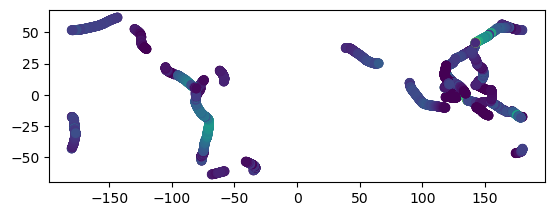

In [ ]:
df=PK.get_subductiondf(10)
df.plot(column='Subduction Volume Rate')

In [20]:
time = 0 #Ma
gplot = gplately.PlotTopologies(PK.model, coastlines=coastlines, continents=continents, time=time) ##gplately plotting object



## Subduction Zone Tessellation

This section:
1. Tessellates all subduction zones into points at regular intervals
2. Calculates subduction parameters (convergence rate, migration rate, etc.)
3. Saves results to avoid re-computation

**Note**: This only needs to be run once. Subsequent runs can skip this step and load the saved parquet file.


In [ ]:
## uses GPlately at backend to calculate all the plate kinematics related parameters

list_subduction_df=[]
for reconstruction_time in range (TO_TIME,FROM_TIME+WINDOW_SIZE+1):
    if reconstruction_time%50==0:
        print(f"Tessellating Subduction at time= {reconstruction_time} Ma")
    
    subduction_df=PK.get_subductiondf(reconstruction_time,  
                                      tessellation_threshold_deg=NETCDF_GRID_RESOLUTION,
                                      velocity_delta_time=TIME_STEPS)
    subduction_df["Time"]=reconstruction_time
    list_subduction_df.append(subduction_df)

all_sz_df=pd.concat(list_subduction_df)
all_sz_df.to_parquet(f"{DEFAULT_OUTPUT_CSV}/ALL_Subduction.paraquet")

#### Read the subduction file once all subduction zone has been tessellated 

In [13]:
all_sz_df=pd.read_parquet(f"{DEFAULT_OUTPUT_CSV}/ALL_Subduction.paraquet") 

Using agegrid file : //Volumes/SatyamData/Merdith1Ga/Merdith_etal_OPTIMISED_gplately2/seafloor_grid_output/SEAFLOOR_AGE/masked/Merdith_etal_2021_OPT_SEAFLOOR_AGE_grid_0Ma.nc


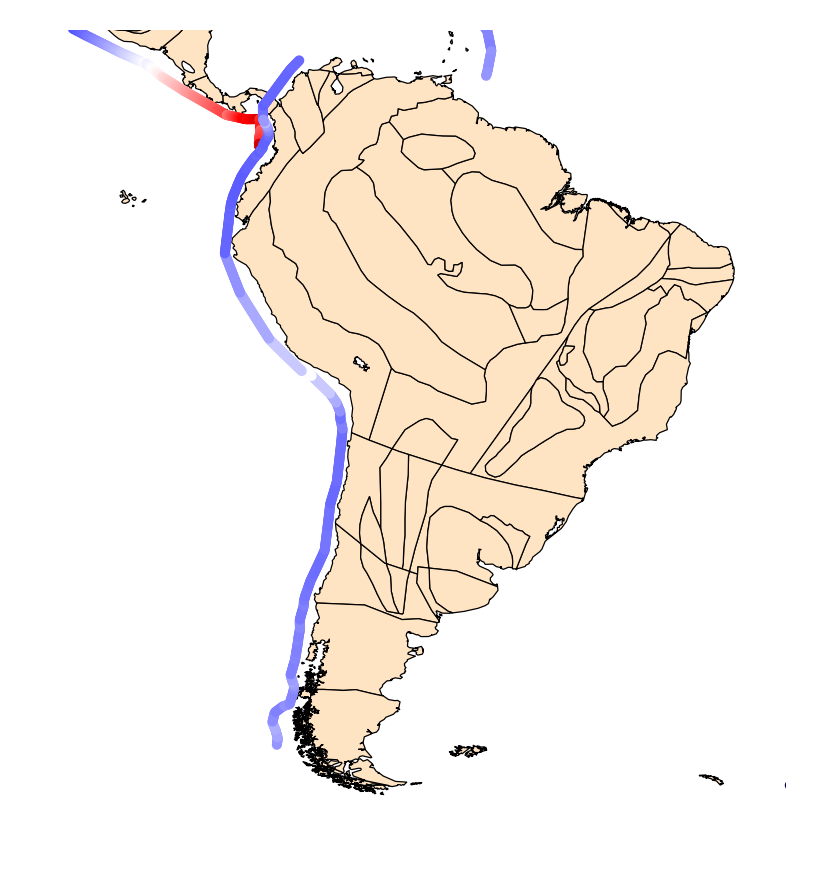

In [14]:
time=0
coastlines_gdf=gpd.read_file(coastlines)
delta=get_cpt.get_cmap("BlueDarkRed18.cpt")
fig,ax=plt.subplots(1,1,figsize=[3,3],dpi=300)
df=PK.get_subductiondf(time)
coastlines_gdf.plot(ax=ax,facecolor='bisque',edgecolor='k',lw=0.3,alpha=1.0)
df.plot(ax=ax,column='Migration Rate',cmap='seismic',markersize=2,legend=False,vmax=0.03,vmin=-0.03)
plt.xlim([-100,-30])
plt.ylim([-60,15])
plt.axis('off')
plt.tight_layout()


In [ ]:
# plt.scatter(TrainingData['Longitude'],TrainingData['Latitude'],c=TrainingData['Trench Distance'])


## Creating Training Points

For each reconstruction time, this workflow:
1. Creates a mesh of points around active subduction zones
2. Points extend up to `threshold_distance_in_kms` from trenches
3. Point density controlled by `mesh_refinement_level`

**Output**: Spatial points with associated trench distances and plate IDs


### Example to create point around trench in deep time

In [24]:
reconstruction_time=200

TrainingData=PK.create_points_around_trench(all_subduction_df=all_sz_df,reconstruction_time=reconstruction_time,
                                tessellation_threshold_deg=NETCDF_GRID_RESOLUTION,
                                threshold_distance_in_kms=3000,
                                mesh_refinement_level=MESH_REFINEMENT_LEVEL)
Data_gdf=gpd.GeoDataFrame(TrainingData,geometry=gpd.points_from_xy(TrainingData['Longitude'],TrainingData['Latitude']),crs='EPSG:4326')


<GeoAxes: >

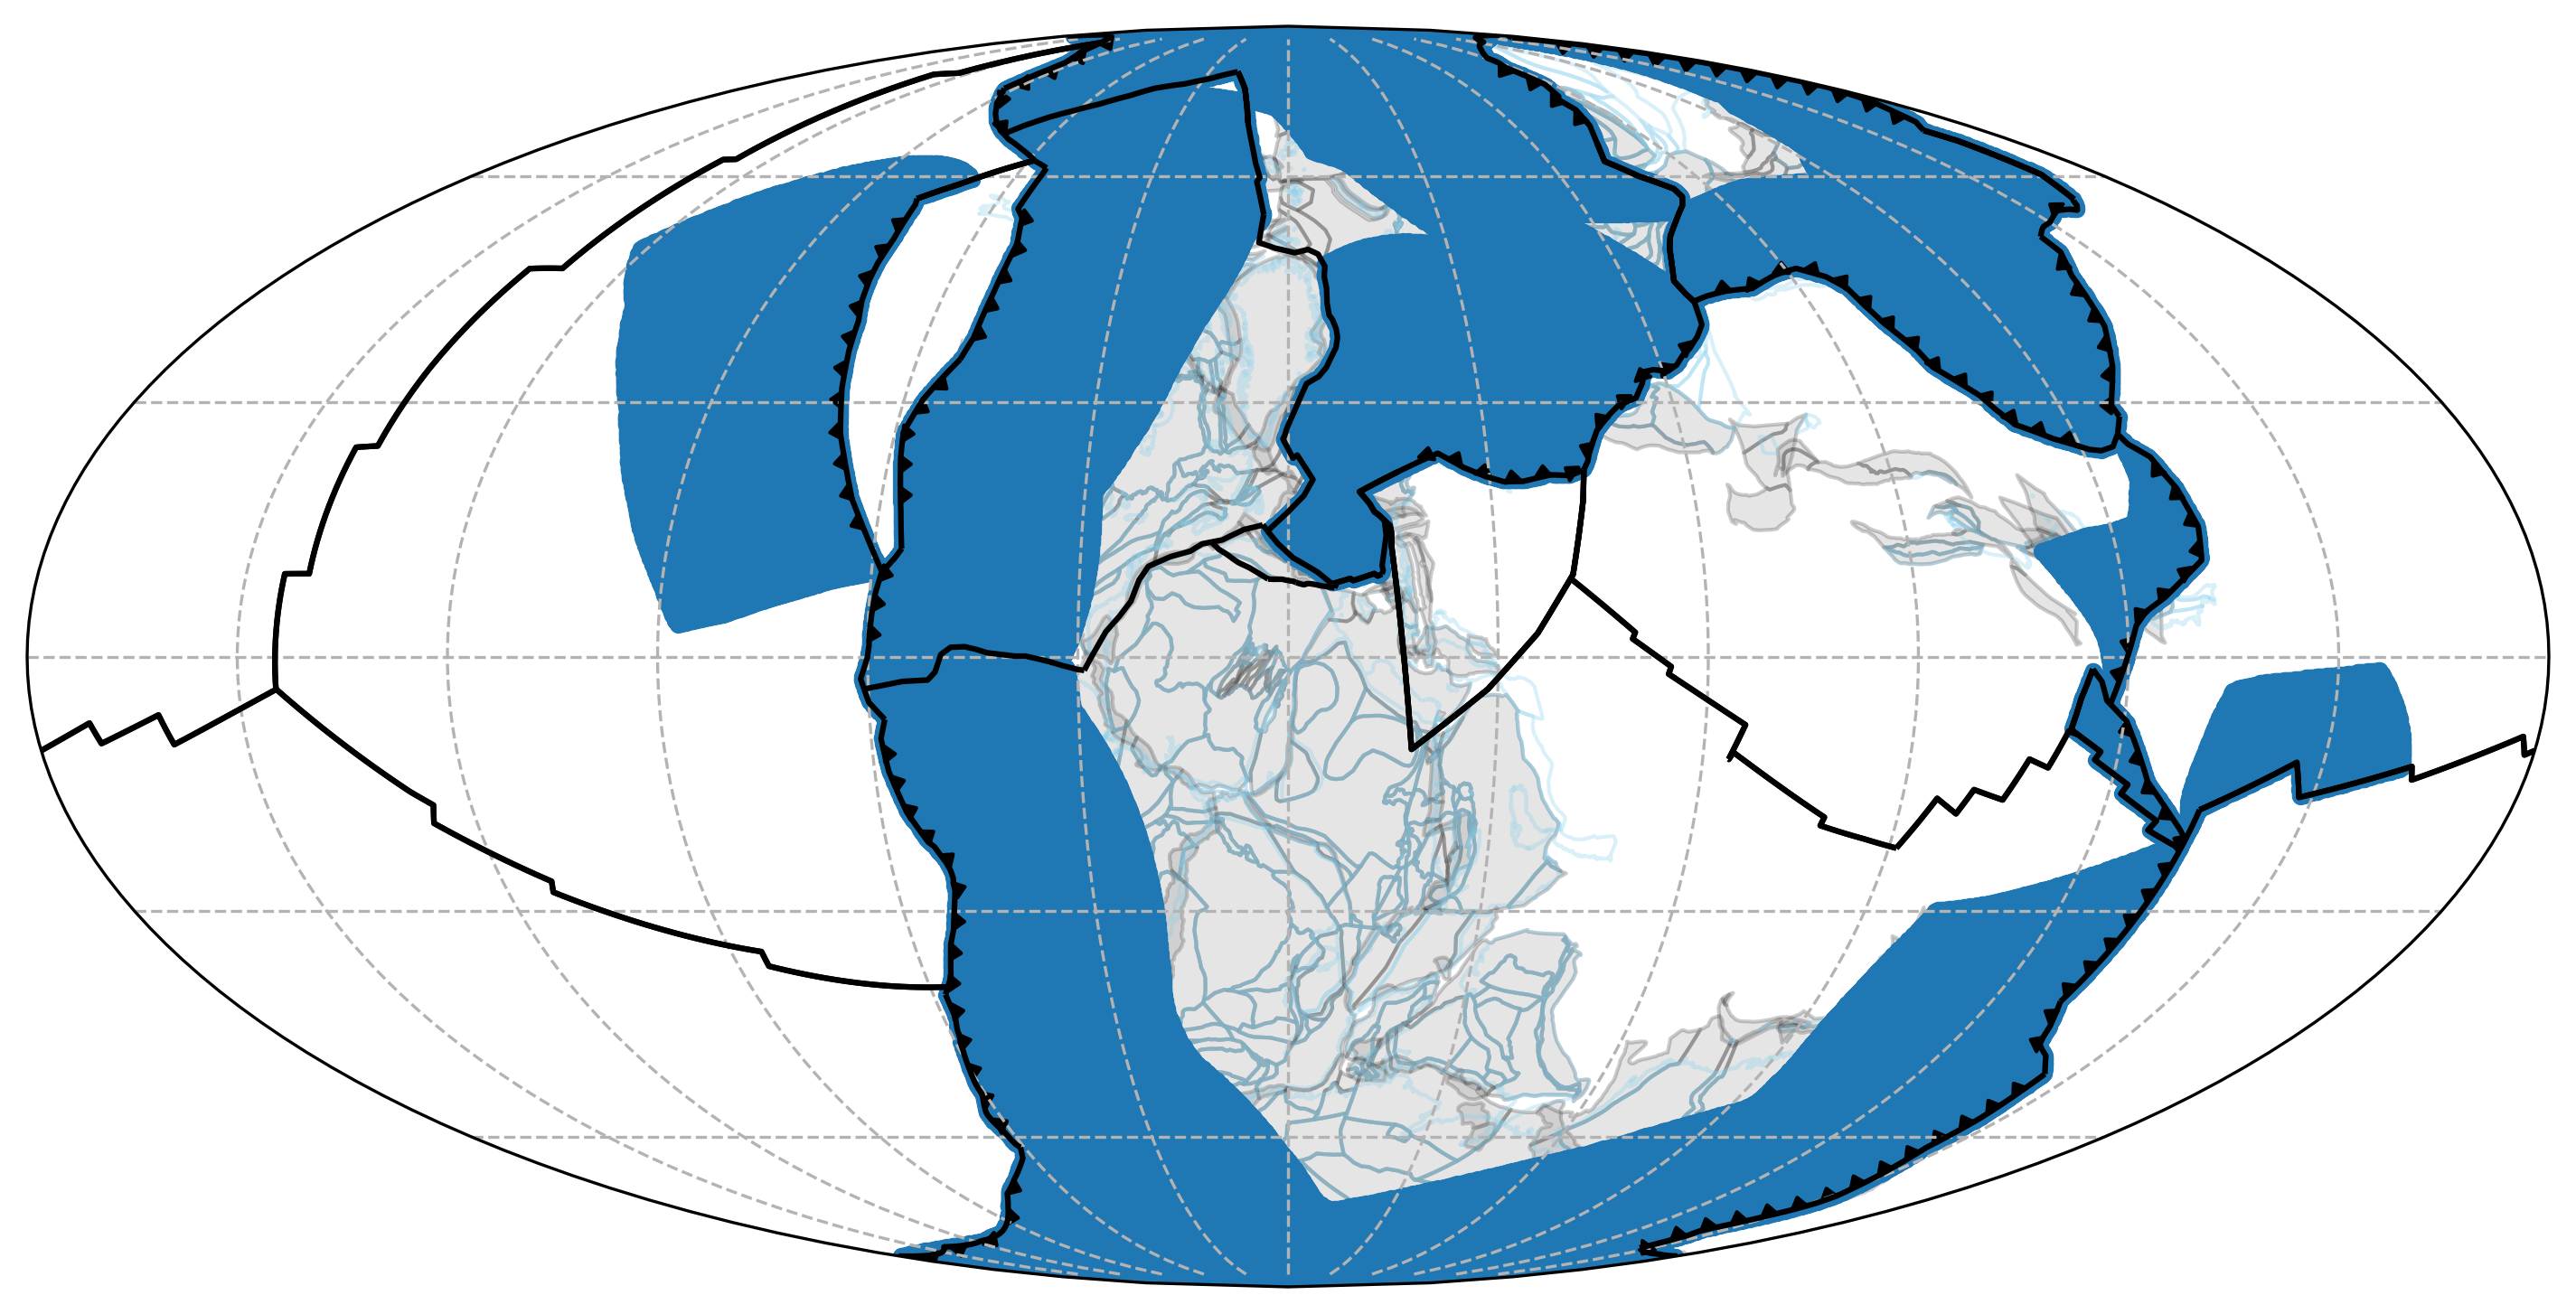

In [25]:
plotgdf(Data_gdf,gplot=gplot,time=reconstruction_time,mollweide=True,quick=False)


## Calculating Mean Subduction Parameters

For each point, this section calculates time-averaged subduction parameters over a moving window:
- Uses past `WINDOW_SIZE` Ma of data
- Can compute weighted or simple means
- Excludes certain columns that would be redundant

**Processing time**: ~5-6 minutes per time step (varies with resolution)


In [19]:


# create_directory_if_not_exists(f"{DEFAULT_OUTPUT_CSV}/Window_Size_{WINDOW_SIZE}_Ma")

# for reconstruction_time in range(TO_TIME,FROM_TIME+1,TIME_STEPS):

#     # if reconstruction_time==100:  # comment this and next line if you want to run to full time step
#     #     break
  

#     print(f"Working on time={reconstruction_time} Ma")
#     training_df=PK.create_points_around_trench(all_subduction_df=all_sz_df,reconstruction_time=reconstruction_time,
#                                    tessellation_threshold_deg=NETCDF_GRID_RESOLUTION,
#                                    mesh_refinement_level=MESH_REFINEMENT_LEVEL)
#     TrainingData=PK.get_plate_kinematics_gplately(training_df,
#                                          all_sz_df,
#                                          reconstruction_time=int(reconstruction_time),
#                                          window_size=int(WINDOW_SIZE),
#                                          weighted_mean=Weighted,
#                                          timesteps=TIME_STEPS,
#                                          exclude_cols=['Trench Longitude','Trench Latitude', 'Longitude', 'Trench Distance'])
    
#     TrainingData.to_parquet(f"{DEFAULT_OUTPUT_CSV}/Window_Size_{WINDOW_SIZE}_Ma/Data_{reconstruction_time}.parquet")
   
#     print("Done!")
 

In [ ]:


def process_reconstruction_time(reconstruction_time):
    print(f"Working on time={reconstruction_time} Ma")
    
    # import pyproj
    # Point pyproj to the correct PROJ data directory
    # os.environ["PROJ_LIB"] = "/Users/ssin4735/miniforge3/envs/EBMTest311/share/proj"
    try:

        pyproj.datadir.set_data_dir(os.environ["PROJ_LIB"])

        training_df = PK.create_points_around_trench(
            all_subduction_df=all_sz_df,
            reconstruction_time=reconstruction_time,
            tessellation_threshold_deg=NETCDF_GRID_RESOLUTION,
            mesh_refinement_level=MESH_REFINEMENT_LEVEL
        )

        TrainingData = PK.get_plate_kinematics_gplately(
            training_df,
            all_sz_df,
            reconstruction_time=int(reconstruction_time),
            window_size=int(WINDOW_SIZE),
            weighted_mean=Weighted,
            timesteps=TIME_STEPS+4,
            exclude_cols=['Trench Longitude','Trench Latitude','Longitude','Latitude']
        )
        # cols_to_drop = ['Humid_Belt_left', 'Humid_Belt_right', 'Humid_Belt']
        # TrainingData = TrainingData.drop(columns=[c for c in cols_to_drop if c in TrainingData.columns])
        # TrainingData=CM.get_time_spent_in_humid_belt(PK.model,TrainingData,reconstruction_time=0,window_size=15,lat_band=10,use_trench=True,
        #                                         drop_fraction =0.8)

        outdir = f"{DEFAULT_OUTPUT_CSV}/Window_Size_{WINDOW_SIZE}_Ma_New"
        os.makedirs(outdir, exist_ok=True)
        TrainingData.to_parquet(f"{outdir}/Data_{reconstruction_time}.parquet")

        print(f"Done with {reconstruction_time} Ma")
    except Exception as e:
        print(f"Error at time={reconstruction_time}: {e}")
        # print(f"Skipping time={reconstruction_time}, file not found")
    return reconstruction_time


# --- Parallel execution ---
# times = range(TO_TIME, FROM_TIME, TIME_STEPS)

# results = Parallel(n_jobs=8)(  # -1 means use all CPUs
#     delayed(process_reconstruction_time)(t) for t in times
# )

times = range(TO_TIME, FROM_TIME, TIME_STEPS)

results = Parallel(n_jobs=4)(  # -1 means use all CPUs
    delayed(process_reconstruction_time)(t) for t in times
)


## Mantle Convection Parameters

### What's Being Sampled:
- **Temperature**: Mantle temperature at multiple depths (MANTLE_depths)
- **Vertical Velocity**: Mantle upwelling/downwelling rates

### Interpolation:
If mantle data isn't available at every timestep, linear interpolation fills gaps.

**Warning**: This creates ~1.5 GB of data per timestep when interpolating.


In [16]:
# Input Files 
MANTLE_MODEL_NAME=PARAMS['InputFiles']['mantle_convection']['model_name']
MANTLE_MODEL_DIR = PARAMS['InputFiles']['mantle_convection']['model_dir']  ## plate model
MANTLE_topology_filenames =[f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['mantle_convection']['topology_files']]
MANTLE_rotation_filenames = [f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['mantle_convection']['rotation_files']]

MANTLE_depths= PARAMS['InputFiles']['mantle_convection']['depth']
MANTLE_vel_folder=PARAMS['InputFiles']['mantle_convection']['new_vel_folder']
MANTLE_temp_folder=PARAMS['InputFiles']['mantle_convection']['new_temp_folder']

MANTLE_org_vel=PARAMS['InputFiles']['mantle_convection']['original_vel_folder']
MANTLE_org_temp=PARAMS['InputFiles']['mantle_convection']['original_temp_folder']


# MANTLE_velx_folder=PARAMS['InputFiles']['mantle_convection']['new_velx_folder']
# MANTLE_org_velx=PARAMS['InputFiles']['mantle_convection']['original_velx_folder']

# MANTLE_vely_folder=PARAMS['InputFiles']['mantle_convection']['new_vely_folder']
# MANTLE_org_vely=PARAMS['InputFiles']['mantle_convection']['original_vely_folder']

# MANTLE_visc_folder=PARAMS['InputFiles']['mantle_convection']['new_visc_folder']
# MANTLE_org_visc=PARAMS['InputFiles']['mantle_convection']['original_visc_folder']

print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print("Reading input file..... \n")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"Mantle Convection Plate Model: {MANTLE_MODEL_NAME} \n")
print(f"Mantle Convection Plate Model Directory: {MANTLE_MODEL_DIR} \n")

print(f"Mantle Convection Velocity: {MANTLE_vel_folder} \n")
print(f"Mantle Convection Temperature: {MANTLE_temp_folder} \n")

print(f"Mantle Convection Velocity: {MANTLE_org_vel} \n")
print(f"Mantle Convection Temperature: {MANTLE_org_temp} \n")

print(f"Mantle Convection Depths: {MANTLE_depths} \n")

print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– \n")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Reading input file..... 

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Mantle Convection Plate Model: Merdith1Ga 

Mantle Convection Plate Model Directory: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions 

Mantle Convection Velocity: /Volumes/SatyamData/Merdith1Ga/CITCOMS/vz_dimensional 

Mantle Convection Temperature: /Volumes/SatyamData/Merdith1Ga/CITCOMS/temp_dimensional 

Mantle Convection Velocity: /Volumes/SatyamData/Merdith1Ga/STLR1GaM3A/STLR1GaM3A_vz_dimensional 

Mantle Convection Temperature: /Volumes/SatyamData/Merdith1Ga/STLR1GaM3A/STLR1GaM3A_temp_dimensional 

Mantle Convection Depths: [16, 31, 47, 62, 140, 155, 171, 186, 202, 217, 233, 268, 293, 323, 357, 396, 439, 487, 540, 597, 660, 726, 798, 874, 954, 1040] 

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 



In [17]:
MT=MantleParameters(original_folder=MANTLE_org_temp,
                    new_folder=MANTLE_temp_folder,
                    parameter_type="Mantle_Temp", 
                    depths=MANTLE_depths, 
                    starttime=TO_TIME,
                    endtime=FROM_TIME,
                    timestep=TIME_STEPS, 
                    anchor_plate_id=Mantle_ID)
VZ=MantleParameters(original_folder=MANTLE_org_vel,
                    new_folder=MANTLE_vel_folder,
                    parameter_type="Mantle_Velocity", 
                    depths=MANTLE_depths, 
                    starttime=TO_TIME,
                    endtime=FROM_TIME,
                    timestep=TIME_STEPS, 
                    anchor_plate_id=Mantle_ID)

Directory already exists: /Volumes/SatyamData/Merdith1Ga/CITCOMS/temp_dimensional
Rotation File not provided!
Topologies not provided
'MantleParameters' object has no attribute 'rotation_model'
Directory already exists: /Volumes/SatyamData/Merdith1Ga/CITCOMS/vz_dimensional
Rotation File not provided!
Topologies not provided
'MantleParameters' object has no attribute 'rotation_model'


### Interpolate Mantle Convection Data at each timesteps.

In case you don't have mantle parameters at uniform time step you can use a linear interpolation. Note that this will create a huge amount of data (~1.5 GB/timesteps)


In [ ]:
MT.interpolate_mantle_data(n_jobs=parallel,required_timesteps=TIME_STEPS)
VZ.interpolate_mantle_data(n_jobs=parallel,required_timesteps=TIME_STEPS)


## Climate Parameters

### Humid Belt Tracking:
Tracks how long each location spent in tropical humid belts (±10° latitude by default):
- Uses **paleomagnetic reference frame** (different from mantle frame)
- Tracks points backward through time
- Calculates fraction of time in humid zone

**Use case**: Erosion rates are higher in humid tropical regions, affecting topography.

---

In [18]:
climate_rotation_filenames = [f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['climate_parameters']['rotation_files']]


CM=ClimateParameters(topology_filenames, 
                             climate_rotation_filenames,
                             static_polygons,
                             agegrid=agegrid,
                             coastlines=coastlines,
                             continents=continents,
                             anchor_plate_id=Paleomag_ID)



In [19]:
all_times=glob.glob(f"{DEFAULT_OUTPUT_CSV}/Window_Size_{WINDOW_SIZE}_Ma_NEW/*")
all_times=np.sort([int(time.split('_')[-1].split('.')[0]) for time in all_times])

In [ ]:
# if Weighted:
create_directory_if_not_exists(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma")

# reconstruction_time=0
for reconstruction_time in all_times[:201]:
# for reconstruction_time in range(0,525):
    try:
        
        print(f"Getting Data at time={reconstruction_time} Ma")
        TrainingData=pd.read_parquet(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma/Processed_Data_{reconstruction_time}.parquet")
        cols_to_drop = ['Humid_Belt_left', 'Humid_Belt_right', 'Humid_Belt']
        TrainingData = TrainingData.drop(columns=[c for c in cols_to_drop if c in TrainingData.columns])
        TrainingData=CM.get_time_spent_in_humid_belt(PK.model,TrainingData,reconstruction_time=0,window_size=15,lat_band=10,use_trench=True,
                                                drop_fraction =0.8)
        

        TrainingData.to_parquet(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma/Processed_Data_{reconstruction_time}.parquet")
       
        print("Processed and saved data!")

    except Exception as e:
        print(f"Error={e}")


# Extract Mantle Convection and Climate Parameters

This section of code will first read the data generated by PlateKinematics and then sample mantle parameters at every location. It will also track the point to calculate time a location spend in Humid Belt

In [ ]:
# if Weighted:
create_directory_if_not_exists(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma_NEW")

# reconstruction_time=0
for reconstruction_time in all_times[17:]:
# for reconstruction_time in range(0,525):
    try:
        
        print(f"Getting Data at time={reconstruction_time} Ma")
        TrainingData=pd.read_parquet(f"{DEFAULT_OUTPUT_CSV}/Window_Size_{WINDOW_SIZE}_Ma_NEW/Data_{reconstruction_time}.parquet")
        TrainingData=MT.get_mantle_parameters(TrainingData,reconstruction_time, depth_wise=True,n_jobs=parallel) ## getting mantle temp
        TrainingData=VZ.get_mantle_parameters(TrainingData,reconstruction_time, depth_wise=True,n_jobs=parallel) ## getting vertical mantle vel
        TrainingData=CM.get_time_spent_in_humid_belt(PK.model,TrainingData,reconstruction_time=0,window_size=15,lat_band=10,use_trench=True,
                                                drop_fraction =0.8)
        
        
        TrainingData.to_parquet(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma_NEW/Processed_Data_{reconstruction_time}.parquet")
       
        print("Processed and saved data!")

    except Exception as e:
        print(f"Error={e}")



## Oceanic Lithospheric Age

### Two-Step Process:

#### 1. Creating Lithospheric Age Grid
#### 2. Sampling Age at Training Points
- Extracts lithospheric age at each training point location
- Adds as new column to training data

**Note**: Young lithosphere is thinner and more thermally buoyant, affecting topography.


In [24]:
# Ensure output directory exists
create_directory_if_not_exists(f"{DEFAULT_OUTPUT_NetCDF}/Interpolated_Seafloor/")

column_for_netcdf1 = "Lithospheric Age"
compression = {'zlib': ZLIB, 'complevel': COMPLEVEL}
encoding = {column_for_netcdf1: compression}
age_grid_masked="/Volumes/SatyamData/Merdith1Ga/AgeGrid_1Ga_OptimisedMantleFrame_run48/masked"

def create_lithospheric_agegrid(reconstruction_time):
    print(f"Working on {reconstruction_time}")
    
    # 1. Load age grid
    age_grid_file = find_filename_with_number(age_grid_masked, reconstruction_time)
    age_grid = xr.open_dataset(age_grid_file)
    
    # 2. Reconstruct continents (use unique tmp file per job)
    tmp_file = f"{DEFAULT_OUTPUT_CSV}/tmp_{reconstruction_time}.shp"
    pygplates.reconstruct(
        continents,
        PK.rotation_model,
        tmp_file,
        reconstruction_time,
        anchor_plate_id=PK.anchor_plate_id
    )
    recon_cgdf = gpd.read_file(tmp_file)
    
    # 3. Prepare point data
    columns = ['lat', 'lon', 'z']
    all_points = age_grid.to_dataframe().reset_index()
    db_gdf = all_points.dropna()
    all_nan = all_points[all_points['z'].isna()]
    all_nan_gdf = gpd.GeoDataFrame(
        all_nan,
        geometry=gpd.points_from_xy(all_nan['lon'], all_nan['lat']),
        crs="EPSG:4326"
    )
    
    # 4. Spatial join with continents
    all_within_continents = gpd.sjoin(
        all_nan_gdf,
        recon_cgdf,
        predicate='within',
        how='left'
    )
    all_within_continents = all_within_continents.dropna(
        subset=['ANCHOR', 'TIME', 'FILE1', 'RECONFILE1', 'PLATEID1', 'FROMAGE', 'TOAGE',
                'NAME', 'PLATEID2', 'GPGIM_TYPE', 'L_PLATE', 'R_PLATE', 'SPREAD_ASY',
                'IMPORT_AGE']
    )
    all_within_continents['z'] = 200
    
    # 5. Combine with valid values
    combined = pd.concat([all_within_continents[columns], db_gdf[columns]])
    combined_cdf = df_to_NetCDF(combined['lon'], combined['lat'], combined['z'])
    
    # 6. Interpolation
    combined_cdf = combined_cdf.interpolate_na(dim="Longitude", method="linear") \
                               .interpolate_na(dim="Latitude", method='linear')
    
    # 7. Save to NetCDF
    combined_cdf = combined_cdf.to_dataset(name=column_for_netcdf1)
    output_file = f"{DEFAULT_OUTPUT_NetCDF}/Interpolated_Seafloor/Age_Grid_{reconstruction_time}.nc"
    combined_cdf.to_netcdf(output_file, encoding=encoding)
    
    # 8. Clean up tmp shapefile files (multiple sidecar files get written by geopandas)
    for ext in [".shp", ".dbf", ".shx", ".cpg", ".prj"]:
        f = tmp_file.replace(".shp", ext)
        if os.path.exists(f):
            os.remove(f)


def sample_lithospheric_age(reconstruction_time):
    try:
        print(f"Working in {reconstruction_time} Ma")
        
        # Load training data
        TrainingData = pd.read_parquet(
            f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma_NEW/Processed_Data_{reconstruction_time}.parquet"
        )
        
        # Load seafloor grid
        age_grid_file = find_filename_with_number(
            f"{DEFAULT_OUTPUT_NetCDF}/Interpolated_Seafloor/",
            reconstruction_time
        )
        
        # Initialize raster object
        Lithospheric_Age = BhuRaster(folder_location=age_grid_file, Raster_Type="Lithospheric_Age")
        
        # Merge raster parameters into training data
        TrainingData = Lithospheric_Age.get_parameters(TrainingData)
        
        # Save updated parquet
        TrainingData.to_parquet(
            f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma_NEW/Processed_Data_{reconstruction_time}.parquet"
        )
    except Exception as e:
        print(e)
        pass




Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/NetCDF/Interpolated_Seafloor/


### Creating a Lithospheric Age Grid

In [ ]:
# Run in parallel
Parallel(n_jobs=-1, backend="loky")(
    delayed(create_lithospheric_agegrid)(reconstruction_time)
    for reconstruction_time in range(TO_TIME, FROM_TIME + 1, TIME_STEPS)
)


### Sampling Lithohspheric Age Grid

In [25]:


# Run in parallel (use all cores, switch to n_jobs=4 if too memory heavy)
Parallel(n_jobs=-1, backend="loky")(
    delayed(sample_lithospheric_age)(reconstruction_time)
    for reconstruction_time in range(TO_TIME, FROM_TIME + 1, TIME_STEPS)
)


Working in 0 Ma
Working in 1 Ma
Working in 2 Ma
Working in 3 Ma
Working in 4 Ma
Working in 5 Ma
Working in 6 Ma
Working in 7 Ma
Working in 8 Ma
Working in 9 Ma


/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Working in 10 Ma


/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/n

Working in 11 Ma


...

/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Working in 190 Ma
Working in 188 Ma


/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Working in 189 Ma
Working in 191 Ma
Working in 192 Ma
Working in 193 Ma
Working in 194 Ma
Working in 195 Ma
Working in 196 Ma
Working in 197 Ma
Working in 198 Ma
Working in 199 Ma
Working in 200 Ma
Working in 201 Ma
[Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV/Processed_25_Ma_NEW/Processed_Data_201.parquet'
Working in 202 Ma
[Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV/Processed_25_Ma_NEW/Processed_Data_202.parquet'
Working in 203 Ma
[Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV/Processed_25_Ma_NEW/Processed_Data_203.parquet'
Working in 204 Ma
[Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV/Processed_25_Ma_NEW/Processed_Data_204.parquet'
Working in 205 Ma
[Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstruct

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

## Data Visualization

The final section provides tools to visualize results:
- Uses GPlately for plate tectonic context
- Color-coded point plots for any parameter
- Automatic scaling (mean ± 2 standard deviations)
- Supports both Mollweide and PlateCarree projections

**Tip**: Change `k=-8` to cycle through different columns for visualization.


In [48]:
reconstruction_time = 150 #Ma
gplot = gplately.PlotTopologies(PK.model, coastlines=coastlines, continents=continents, time=reconstruction_time)


In [49]:
TrainingData=pd.read_parquet(f"{DEFAULT_OUTPUT_CSV}/Processed_{WINDOW_SIZE}_Ma/Processed_Data_{reconstruction_time}.parquet")
Data_gdf=gpd.GeoDataFrame(TrainingData,geometry=gpd.points_from_xy(TrainingData['Longitude'],TrainingData['Latitude']))
Data_gdf=gpd.GeoDataFrame(TrainingData,geometry=gpd.points_from_xy(TrainingData['Longitude'],TrainingData['Latitude']),crs='EPSG:4326')


<GeoAxes: >

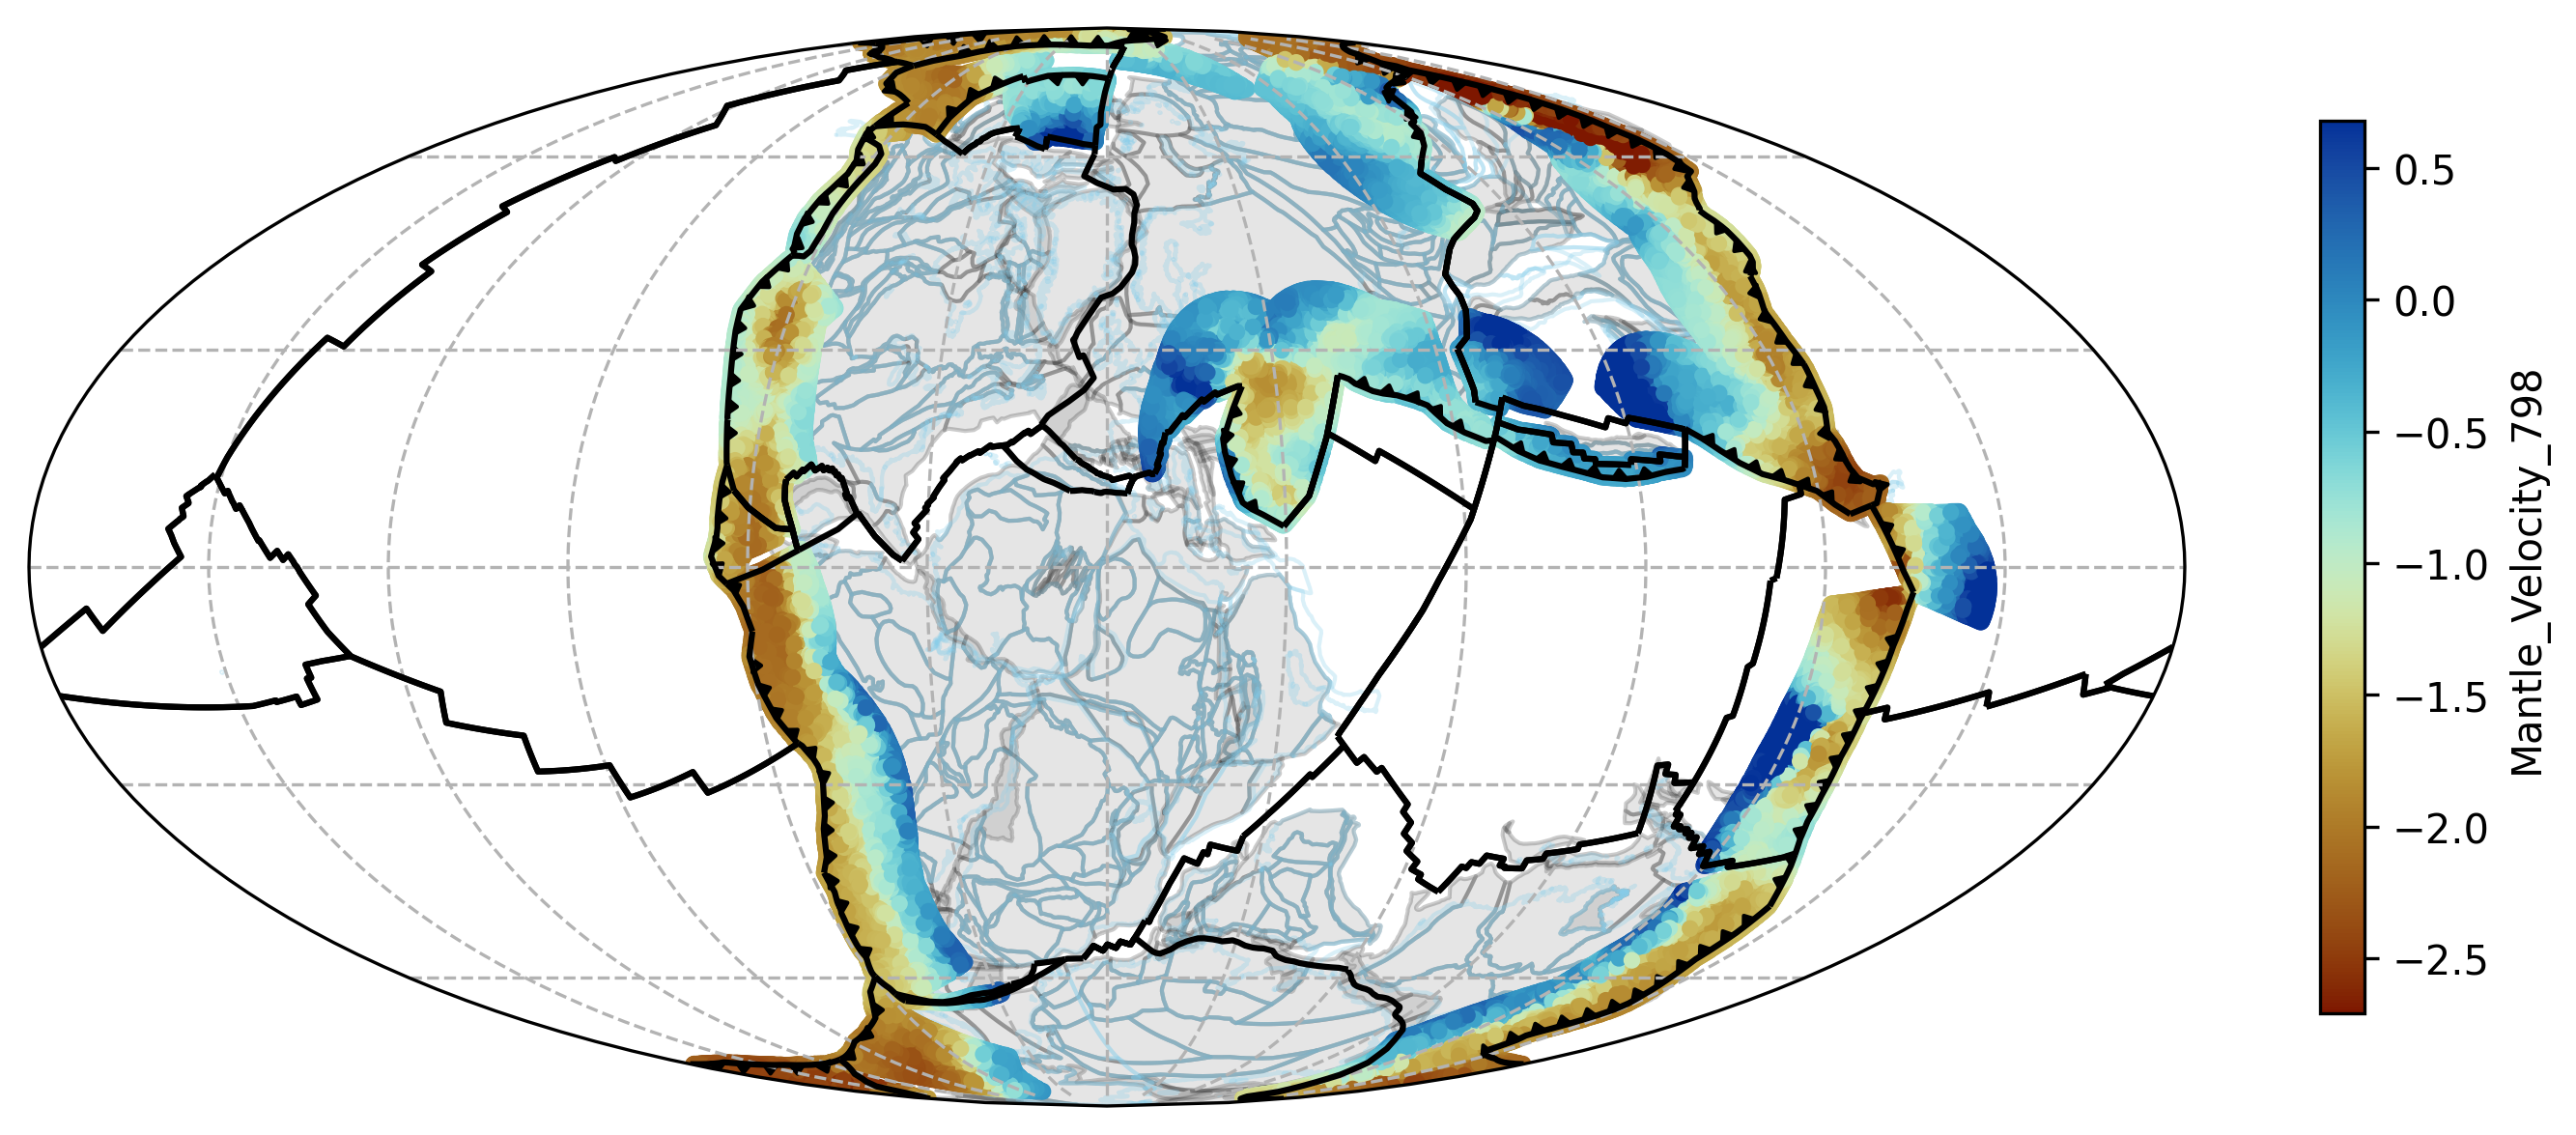

In [55]:
k=-8
columns=Data_gdf.columns
column=columns[k]

data = Data_gdf[column]
# Calculate mean and standard deviation
mean = data.mean()
std = data.std()

# Calculate vmin and vmax
vmin = mean - 2 * std
vmax = mean + 2 * std
kwargs={'vmin':vmin,'vmax':vmax,'cmap':cmc.roma,'label':column}



plotgdf(Data_gdf,gplot=gplot,time=reconstruction_time,column=column,cbar=True,mollweide=True,quick=False,**kwargs)

<GeoAxes: >

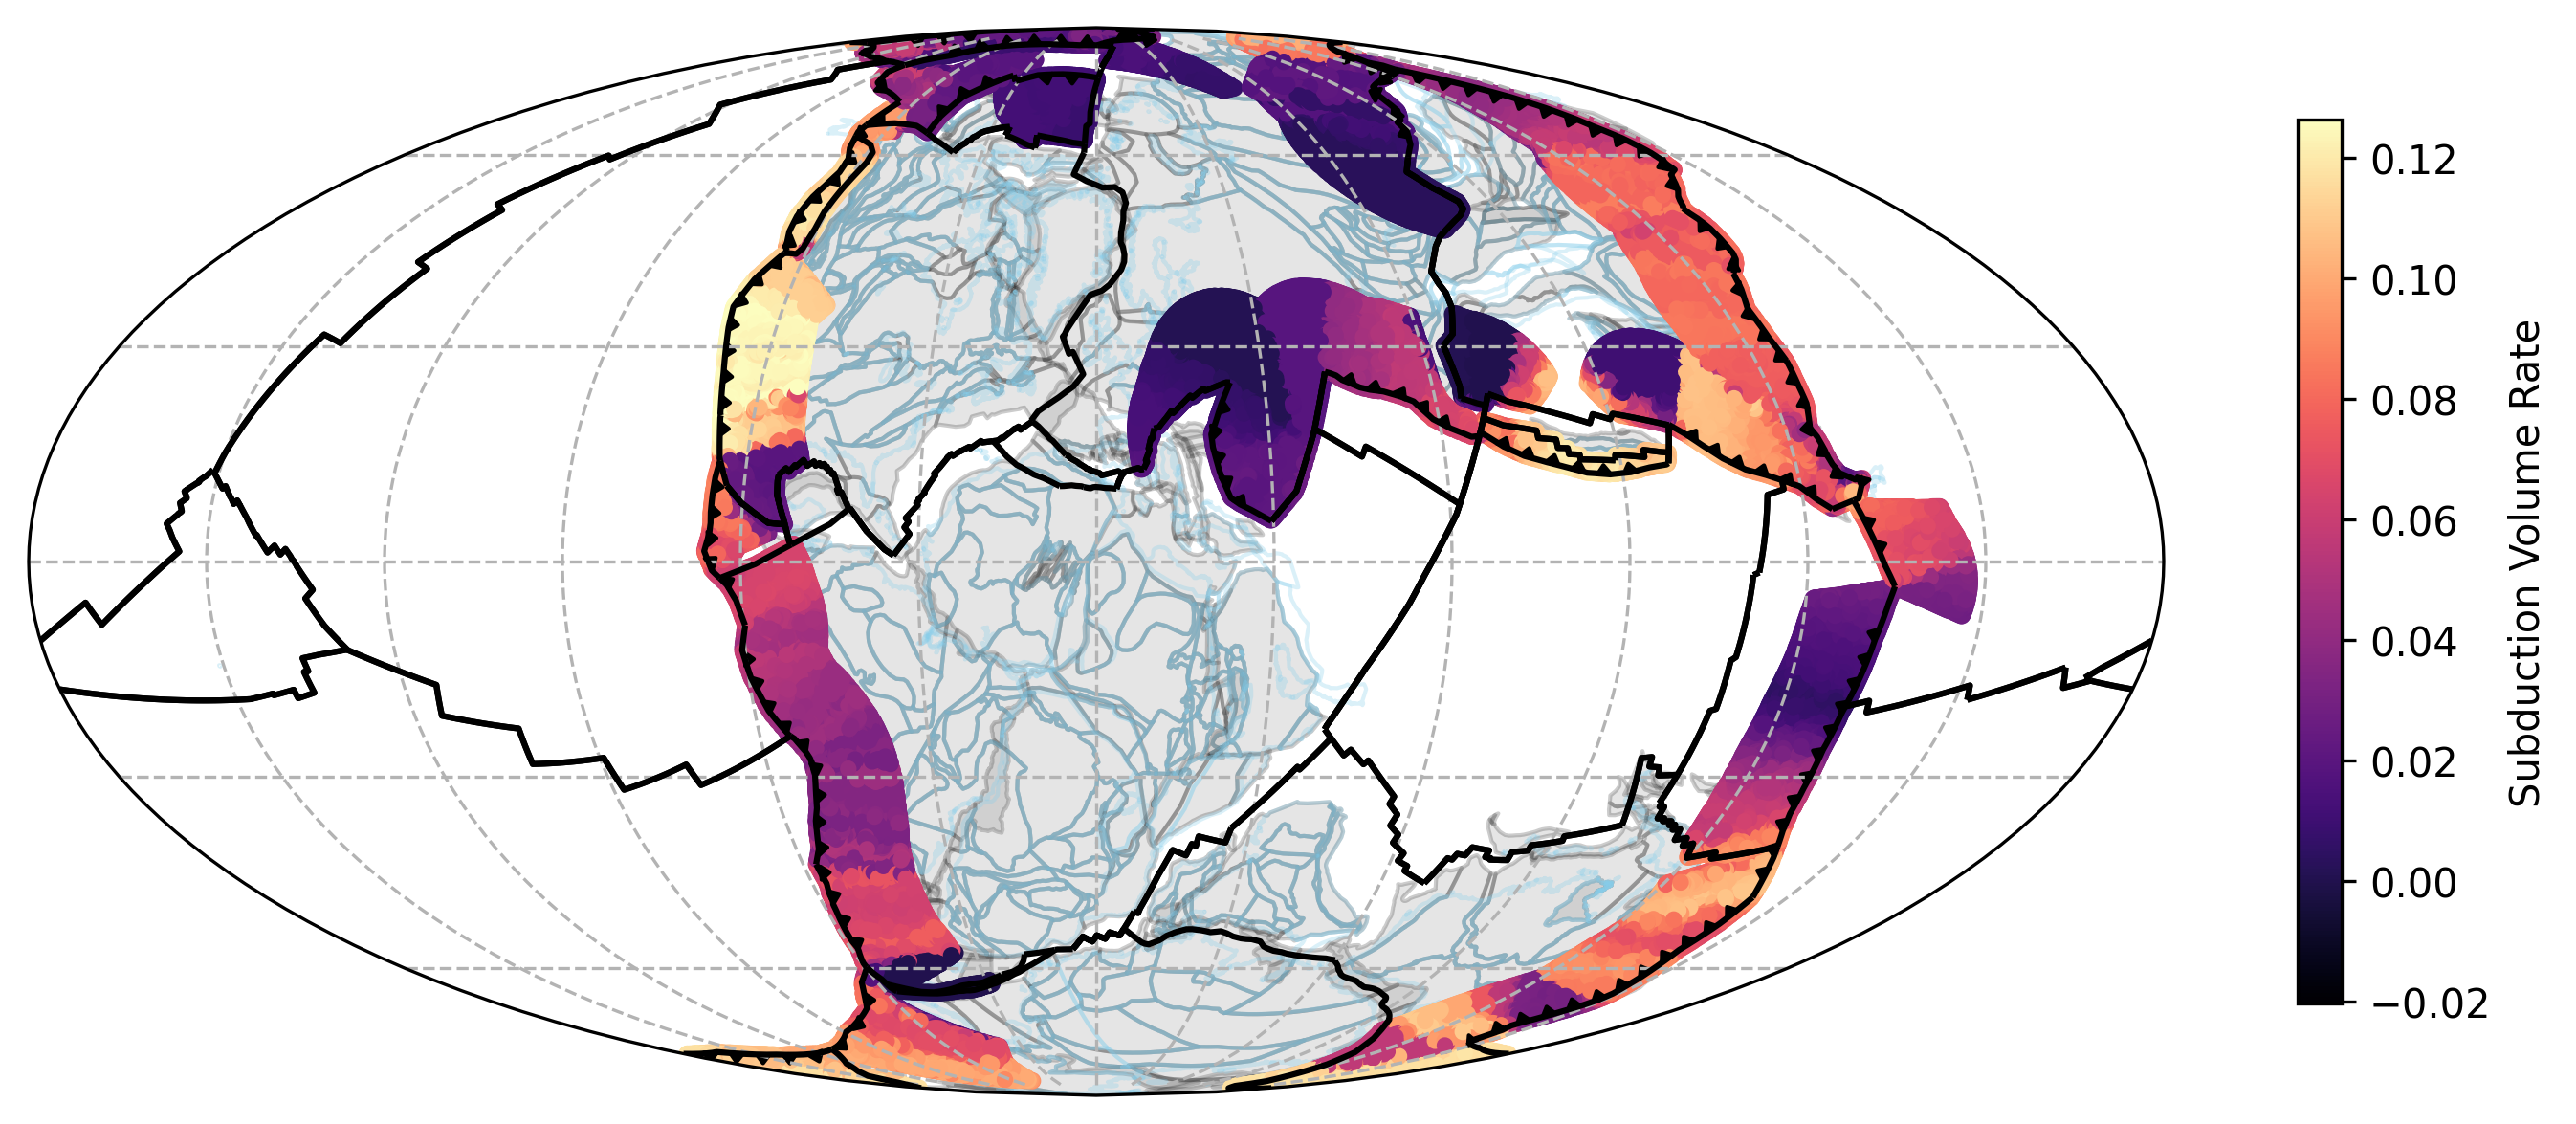

In [54]:
column='Subduction Volume Rate'

data = Data_gdf[column]
# Calculate mean and standard deviation
mean = data.mean()
std = data.std()

# Calculate vmin and vmax
vmin = mean - 2 * std
vmax = mean + 2 * std
kwargs={'vmin':vmin,'vmax':vmax,'cmap':'magma','label':column}



plotgdf(Data_gdf,gplot=gplot,time=reconstruction_time,column=column,cbar=True,mollweide=True,quick=False,**kwargs)

## ⚠️ Important Notes

1. **Run Time**: Complete workflow can take 6-24 hours depending on:
   - Time range (FROM_TIME to TO_TIME)
   - Grid resolution (NETCDF_GRID_RESOLUTION)
   - Number of parallel processes

2. **Memory**: High-resolution runs require substantial RAM (32+ GB recommended)

3. **Storage**: Expect 10-100 GB of output data depending on settings

4. **Checkpointing**: Data is saved at each stage, allowing restart from failures


## 🔄 Workflow Order

Run sections in this order:
1. Load configuration
2. Tessellate subduction zones (once)
3. Create training points with plate kinematics
4. Sample mantle parameters
5. Calculate climate parameters
6. Create and sample lithospheric age
7. Visualize results

**Optional**: Steps 3-6 can be parallelized using the `parallel` parameter.
